# Student Marks Analysis

## Project Overview

This project analyzes student academic performance using Python. It explores relationships between study habits, attendance, failures, and final grades through data cleaning, visualization, and exploratory data analysis (EDA).

**Author:** Samay Kumar Sinha

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [5]:
from google.colab import files

uploaded = files.upload()

Saving student-mat.csv to student-mat.csv


In [6]:
df = pd.read_csv("student-mat.csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [7]:
print("Shape:", df.shape)

print()

df.info()

print()

df.describe(include="all")

Shape: (395, 33)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    obje

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,395,395,395.000000,395.000000,395.000000,395,395,395,395,395,395,395,395,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,4,3,NaN,NaN,NaN,2,2,2,2,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,course,mother,NaN,NaN,NaN,no,yes,no,yes,yes,yes,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,145,273,NaN,NaN,NaN,344,242,214,201,314,375,329,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,NaN,NaN,1.448101,2.035443,0.334177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,NaN,NaN,0.697505,0.839240,0.743651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,NaN,NaN,2.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000


In [8]:
# Check missing values

print(df.isnull().sum())

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (395, 33)


In [11]:
print(df.dtypes)

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


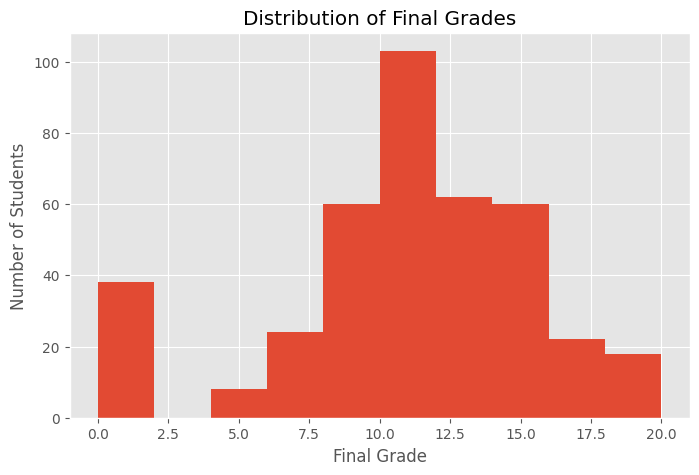

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['G3'], bins=10)

plt.title("Distribution of Final Grades")

plt.xlabel("Final Grade")

plt.ylabel("Number of Students")

plt.show()

### Insight

Most students scored between 10 and 15 marks, indicating an average overall academic performance.

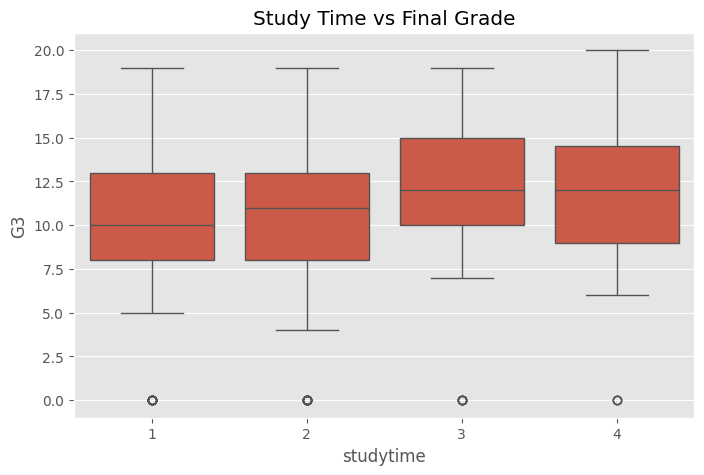

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x='studytime', y='G3', data=df)

plt.title("Study Time vs Final Grade")

plt.show()

Students who spend more time studying generally achieve better final grades.

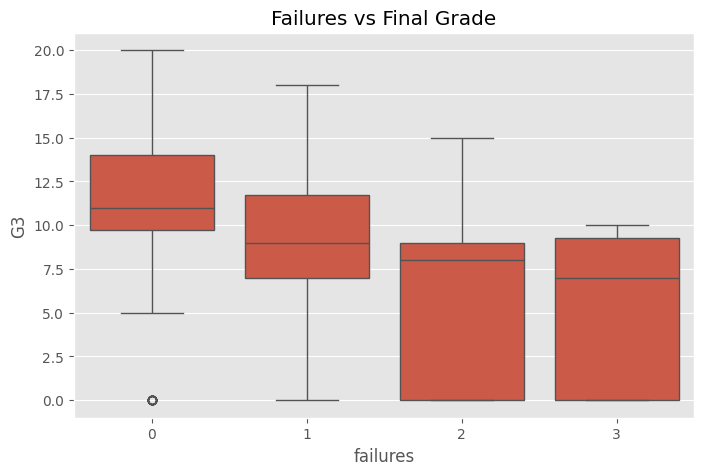

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x='failures', y='G3', data=df)

plt.title("Failures vs Final Grade")

plt.show()

Students who spend more time studying generally achieve better final grades.

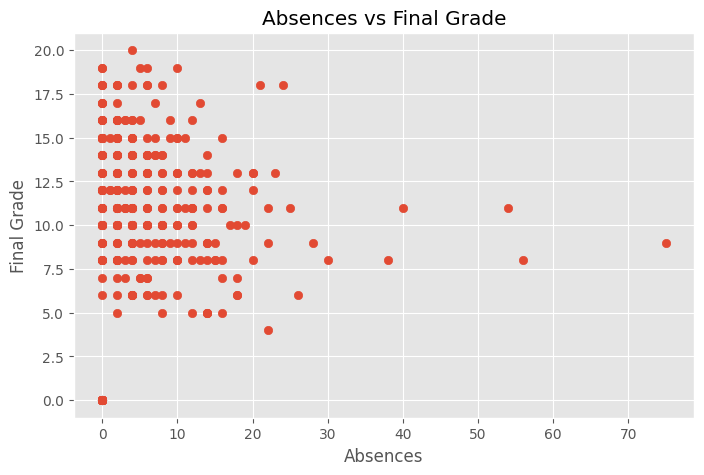

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(df['absences'], df['G3'])

plt.title("Absences vs Final Grade")

plt.xlabel("Absences")

plt.ylabel("Final Grade")

plt.show()

Higher absences generally correspond to lower grades, though there are some exceptions.

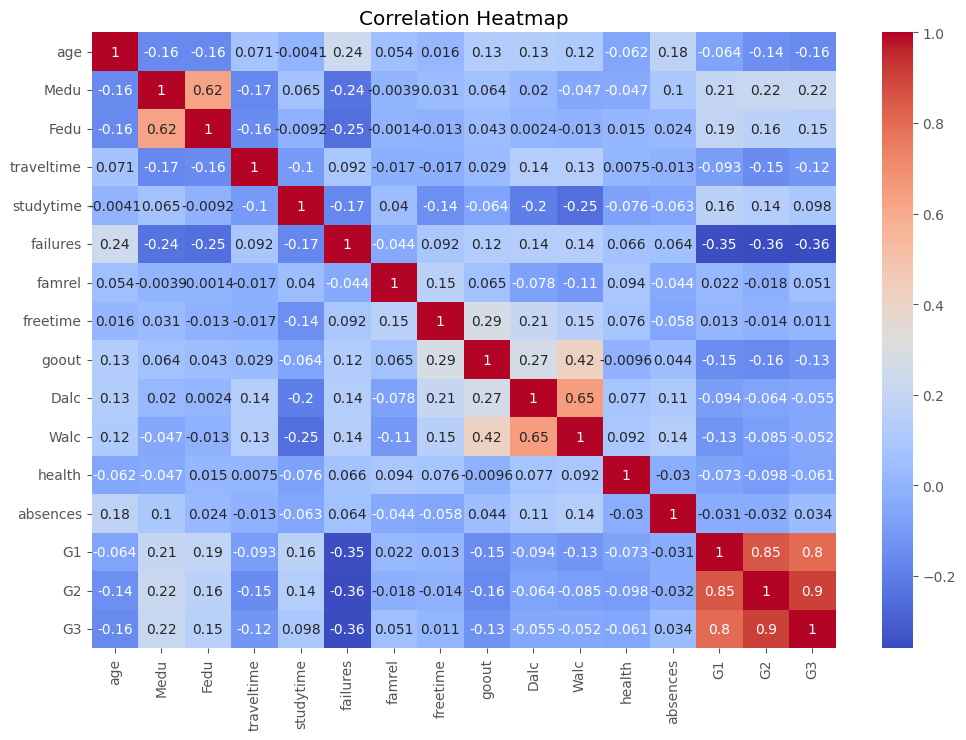

In [16]:
plt.figure(figsize=(12,8))

numeric = df.select_dtypes(include=['number'])

sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [17]:
top_students = df.sort_values(by='G3', ascending=False).head(10)

top_students[['G1','G2','G3']]

,G1,G2,G3
47,19,19,20
286,18,18,19
374,19,18,19
110,18,19,19
8,16,18,19
113,18,19,19
91,16,17,18
42,19,18,18
36,15,16,18
104,16,18,18


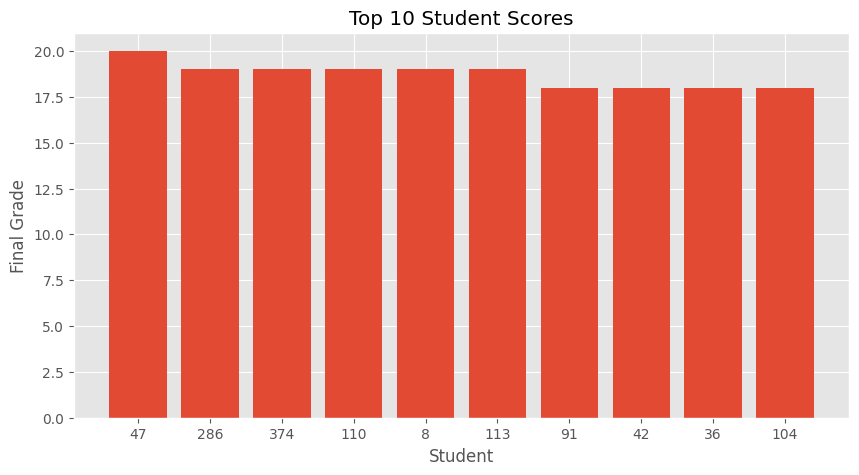

In [18]:
plt.figure(figsize=(10,5))

plt.bar(range(len(top_students)), top_students['G3'])

plt.xticks(range(len(top_students)),
           top_students.index)

plt.title("Top 10 Student Scores")

plt.xlabel("Student")

plt.ylabel("Final Grade")

plt.show()

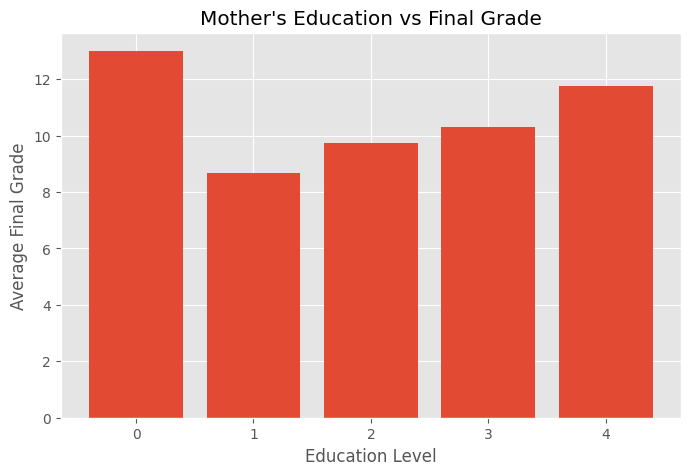

In [19]:
parent = df.groupby('Medu')['G3'].mean()

plt.figure(figsize=(8,5))

plt.bar(parent.index.astype(str), parent.values)

plt.title("Mother's Education vs Final Grade")

plt.xlabel("Education Level")

plt.ylabel("Average Final Grade")

plt.show()

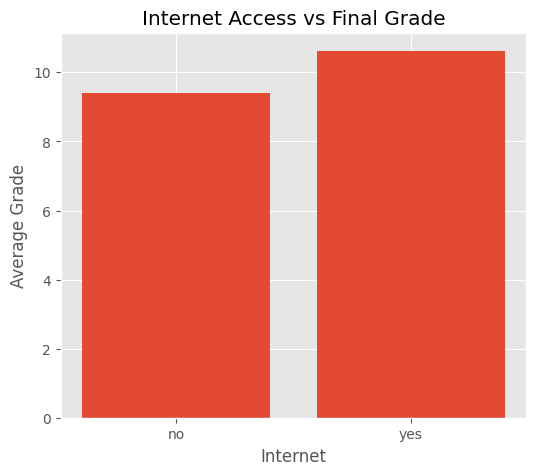

In [20]:
internet = df.groupby('internet')['G3'].mean()

plt.figure(figsize=(6,5))

plt.bar(internet.index, internet.values)

plt.title("Internet Access vs Final Grade")

plt.xlabel("Internet")

plt.ylabel("Average Grade")

plt.show()

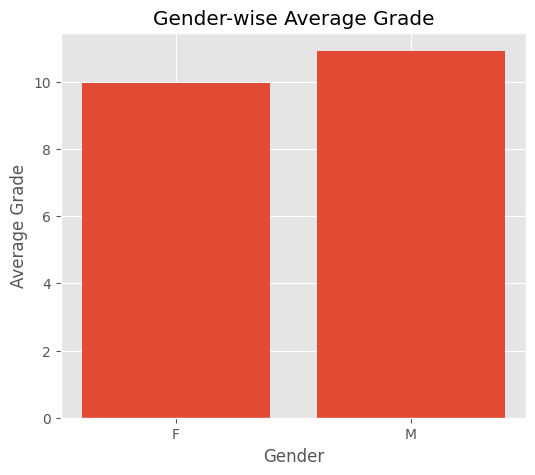

In [21]:
gender = df.groupby('sex')['G3'].mean()

plt.figure(figsize=(6,5))

plt.bar(gender.index, gender.values)

plt.title("Gender-wise Average Grade")

plt.xlabel("Gender")

plt.ylabel("Average Grade")

plt.show()

In [22]:
df.to_csv("student_marks_cleaned.csv", index=False)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


# Conclusion

This project analyzed student academic performance using Python.

## Key Findings

- Students with more study time generally scored higher.
- Previous failures negatively impacted final grades.
- Excessive absences were associated with lower performance.
- Parents' education and internet access showed a positive relationship with academic achievement.
- Visualizations helped identify important trends in student performance.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## Skills Demonstrated

- Data Cleaning
- Exploratory Data Analysis
- Statistical Analysis
- Data Visualization